In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point, LineString
from opentnsim import graph

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr

# load OpenTNSim modules
from opentnsim.core import Identifiable, Movable 
from opentnsim.core.vessel_properties import VesselProperties
from opentnsim.graph import HasMultiDiGraph
from opentnsim.vessel_traffic_service import VesselTrafficService
from opentnsim.port.mixins.port import IsPort, HasPortAccess
from opentnsim.port.mixins.terminal import IsTerminal, HasTerminal
from opentnsim.port.mixins.berth import IsJetty, IsQuay
from opentnsim.port.mixins.anchorage_area import IsAnchorage, PassesAnchorage
from opentnsim.port.mixins import tidal_accessibility
from opentnsim.port.mixins.tidal_accessibility import HasDraughtRestrictions
from opentnsim.port.rule_constructor import vessel_characteristics, vessel_direction, vessel_type
from opentnsim.port.tidal_window_constructor import vessel_specifications, \
                                                    vertical_tidal_window_specifications, \
                                                    vertical_tidal_window_input, \
                                                    horizontal_tidal_window_specifications, \
                                                    horizontal_tidal_window_method, \
                                                    horizontal_tidal_window_input, \
                                                    tidal_period, \
                                                    accessibility, \
                                                    NetworkProperties

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np
import scipy

# package(s) for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


In [2]:
%load_ext autoreload
%autoreload 2

#### 1. Constants

In [3]:
# Environment  
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2024, 1, 3, 0, 0, 0)
timestep = pd.Timedelta(minutes=5)
time_series = pd.date_range(simulation_start,simulation_stop,freq=timestep)

In [4]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [5]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (HasPortAccess,
     HasTerminal,
     PassesAnchorage,
     HasDraughtRestrictions,
     HasMultiDiGraph,
     Identifiable, # allows to give the object a name and a random ID,
     Movable,      # allows the object to move, with a fixed speed, while logging this activity
     VesselProperties,
    ), 
    {}
)

In [6]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    yield from vessel.move()

#### 2. Create simulation
We define a function

In [43]:
def determine_tidal_window_length(arr):
    values, counts = np.unique(arr, return_counts=True)
    tidal_window_length = 0.
    if len(values) == 1:
        tidal_window_length = values[0]
    for value, count in zip(values, counts):
        if count > 1 and value > tidal_window_length:
            tidal_window_length = value  
    return tidal_window_length

def create_and_run_env_with_tidal_window(
    original_waterway_depth,
    added_depth,
    waterway_length, 
    ukc_percentage,
    tidal_range_sea,
    tidal_period,
    tidal_amplication,
    tidal_propagation_speed,
    interarrival_time,
    vessel_beam,
    vessel_draught,
    vessel_speed,
    vessel_loading_factor,
):
    env = simpy.Environment(initial_time=simulation_start.timestamp())
    env.simulation_start = simulation_start
    env.simulation_stop = simulation_stop
    env.epoch = simulation_start

    # Graph
    coordinates_sea = (0,0)
    coordinates_port = geod.fwd(coordinates_sea[0], coordinates_sea[1], 90 ,waterway_length) # East from Point 0
    coordinates_waterway = {"Sea": (coordinates_sea[0], coordinates_sea[1]),
                            "Port basin": (coordinates_port[0], coordinates_port[1]),}
    FG = nx.DiGraph()
    for name, coordinate in coordinates_waterway.items():
        FG.add_node(name, geometry=Point(coordinate[0], coordinate[1]))
    edges = [("Sea", "Port basin"), ("Port basin", "Sea")]
    for edge in edges:
        FG.add_edge(edge[0], edge[1], geometry=LineString([Point(coordinates_sea),Point(coordinates_port[:-1])]), weight=1, length_m=waterway_length)
    env.graph = FG

    # Hydrodynamic data
    waterway_depth = original_waterway_depth + added_depth
    hydrodynamic_data = xr.Dataset()
    tidal_phase_shift = pd.Timedelta(seconds=waterway_length/tidal_propagation_speed)
    tidal_water_level_sea = (tidal_range_sea/2)*np.sin(2*np.pi*((time_series-simulation_start)/(tidal_period*pd.Timedelta(hours=1))))
    amplification_factor = ((tidal_amplication-(1/10000))*waterway_length+1)
    tidal_water_level_port = amplification_factor*(tidal_range_sea/2)*np.sin(2*np.pi*((time_series-simulation_start-tidal_phase_shift)/(tidal_period*pd.Timedelta(hours=1))))
    water_level_data = xr.DataArray(data=[tidal_water_level_sea,tidal_water_level_port],coords={'STATION':FG.nodes,'TIME':time_series})
    MBLs = waterway_depth*np.ones(len(time_series))
    MBL_data = xr.DataArray(data=[MBLs,MBLs],coords={'STATION':FG.nodes,'TIME':time_series})
    hydrodynamic_data['Water level'] = water_level_data
    hydrodynamic_data['MBL'] = MBL_data
    vessel_traffic_service = VesselTrafficService(hydrodynamic_data = hydrodynamic_data)
    env.vessel_traffic_service = vessel_traffic_service
    
    network_properties = NetworkProperties()
    for index, node in enumerate(FG.nodes):
        FG.nodes[node]['Vertical tidal restriction'] = {}
        vertical_tidal_window_inputs = []
    
        vessel_specification = vessel_specifications({vessel_characteristics.min_ge_Draught: 0.0},'x',vessel_direction.inbound)
        window_specification = vertical_tidal_window_specifications(ukc_s = 0.,
                                                                    ukc_p = ukc_percentage/100,
                                                                    fwa = 0.,)
        
        vertical_tidal_window_inputs.append(vertical_tidal_window_input(vessel_specifications = vessel_specification,
                                                                        window_specifications = window_specification))

        vessel_specification = vessel_specifications({vessel_characteristics.min_ge_Draught: 0.0},'x',vessel_direction.outbound)
        window_specification = vertical_tidal_window_specifications(ukc_s = 0.,
                                                                    ukc_p = ukc_percentage/100,
                                                                    fwa = 0.,)
        
        vertical_tidal_window_inputs.append(vertical_tidal_window_input(vessel_specifications = vessel_specification,
                                                                        window_specifications = window_specification))
    
        network_properties.append_vertical_tidal_restriction_to_network(env.graph,node,vertical_tidal_window_inputs)
        
    # Infrastructure
    max_draught = np.max([vessel_draught,vessel_draught+vessel_draught*vessel_loading_factor/100])
    always_sufficient_depth = max_draught + tidal_range_sea + (ukc_percentage/100)*max_draught + 0.5 # m (not important, should be 100% accessible) 

    port = IsPort(env=env, name = "Port", port_entry_nodes=['Sea'])
    anchorage = IsAnchorage(env=env, capacity=20, name = 'Anchorage', node = 'Sea', depth = always_sufficient_depth, geometry=env.graph.nodes['Sea']['geometry'], port = port)
    jetty = IsJetty(env=env,length=300, depth=always_sufficient_depth, name='Jetty',node='Port basin')
    terminal = IsTerminal(env=env, name = 'Terminal', berths=[jetty], port = port)

    # Vessel
    path = nx.dijkstra_path(env.graph, "Sea", "Port basin")
    data_vessel = {
        "env": env,                                       # needed for simpy simulation
        "name": "Vessel 1",                               # required by Identifiable
        "geometry": env.graph.nodes[path[0]]['geometry'], # required by Locatable
        "route": path,                                    # required by Routeable
        "v": vessel_speed,                                # required by Movable, 1 m/s to check if the distance is covered in the expected time
        "bound": 'inbound',
        "terminal": terminal,
        "berthing_time":15, #minutes
        "loading_time": 12, #hours
        "deberthing_time":5, #minutes,
        "next_destination":"Sea",
        "type":"tanker",
        "loading_factor":vessel_loading_factor,
        "L":vessel_beam*8,
        "B":vessel_beam,
        "T":vessel_draught,
    } 
    vessel = Vessel(**data_vessel)
    vessel.mission = env.process(mission(env, vessel))
    env.run()
    try:
        inbound_window_lengths = [(window[1]-window[0]).total_seconds() for window in vessel.tidal_window_calculations[0]['vertical_tidal_windows']]
        inbound_window_length = pd.Timedelta(seconds=0).total_seconds()
        if len(inbound_window_lengths):
            inbound_window_length = determine_tidal_window_length(inbound_window_lengths)
            inbound_window_length = np.min([inbound_window_length,pd.Timedelta(hours=tidal_period).total_seconds()])
            
    except:
        inbound_window_length = pd.Timedelta(seconds=0).total_seconds()
    try:
        outbound_window_lengths = [(window[1]-window[0]).total_seconds() for window in vessel.tidal_window_calculations[1]['vertical_tidal_windows']]
        outbound_window_length = pd.Timedelta(seconds=0).total_seconds()
        if len(outbound_window_lengths):
            outbound_window_length = determine_tidal_window_length(outbound_window_lengths)
            outbound_window_length = np.min([outbound_window_length,pd.Timedelta(hours=tidal_period).total_seconds()])
    except:
        outbound_window_length = pd.Timedelta(seconds=0).total_seconds()
    inbound_vessel_capacity = np.floor(inbound_window_length/interarrival_time.total_seconds())
    outbound_vessel_capacity = np.floor(outbound_window_length/interarrival_time.total_seconds())
    dredging = added_depth*waterway_length*(3*vessel.B)
    return inbound_vessel_capacity, outbound_vessel_capacity, dredging, vessel

#### 3. Run simulation

Outbound


**run simulation**

In [44]:
original_waterway_depth = 11.0

inbound_water_transport_capacity_performances = {}
outbound_water_transport_capacity_performances = {}
dredging_performances = {}
# Looping over waterway length
for waterway_length in [10000, 25000, 50000, 100000]:
    inbound_water_transport_capacity_performance = {}
    outbound_water_transport_capacity_performance = {}
    dredging_performance = {}

    # looping over waterway depth
    for added_depth in np.arange(-2, 2, 0.1):
        waterway_depth = original_waterway_depth + added_depth
        inbound_waterway_capacity_for_design_vessel, outbound_waterway_capacity_for_design_vessel, dredging, vessel = create_and_run_env_with_tidal_window(
            original_waterway_depth = original_waterway_depth, #in m (better known as NGD: nautical guaranteed depth or MBL: maintained bed level)
            added_depth = added_depth,
            waterway_length = waterway_length, #in m 
            ukc_percentage = 10.0, #in % of draught (10% of draught is common)
            tidal_range_sea = 2.0, #in m
            tidal_period = 12.50, # hrs (semi-diurnal tide, most common tide)
            tidal_amplication = 1.0 / 10000, #in m^-1 (amplification factor per 10 km: 1.0 = not damping / amplifying)
            tidal_propagation_speed = 15.0, # m/s (could be calculated using np.sqrt(9.81*waterway_depth))
            interarrival_time = pd.Timedelta(minutes=20),
            vessel_draught = 7, #in m
            vessel_beam = 30,
            vessel_speed = 6.0, # m/s (common speed in confined waterways)
            vessel_loading_factor = 30.0, #in % of draught (+ = loading when export terminal, - = unloading when import terminal, 30% is common)
        )
        inbound_water_transport_capacity_performance[added_depth] = int(inbound_waterway_capacity_for_design_vessel)
        outbound_water_transport_capacity_performance[added_depth] = int(outbound_waterway_capacity_for_design_vessel)
        dredging_performance[added_depth] = dredging
        
    inbound_water_transport_capacity_performances[waterway_length] = inbound_water_transport_capacity_performance
    outbound_water_transport_capacity_performances[waterway_length] = outbound_water_transport_capacity_performance
    dredging_performances[waterway_length] = dredging_performance

C:\Users\floorbakker\OpenTNSim\opentnsim\port\mixins\port.py:142: UserWarning: The port is not accessible for the outbound trip of vessel with id: 54576ddd-b54d-4b66-8911-8b2126d38939
  warnings.warn(f"The port is not accessible for the outbound trip of vessel with id: {vessel.id}")
C:\Users\floorbakker\OpenTNSim\opentnsim\port\mixins\port.py:142: UserWarning: The port is not accessible for the outbound trip of vessel with id: 54576ddd-b54d-4b66-8911-8b2126d38939
  warnings.warn(f"The port is not accessible for the outbound trip of vessel with id: {vessel.id}")
C:\Users\floorbakker\OpenTNSim\opentnsim\port\mixins\port.py:142: UserWarning: The port is not accessible for the outbound trip of vessel with id: 3acfdeab-9719-4ab6-94c3-4c8f5def9da1
  warnings.warn(f"The port is not accessible for the outbound trip of vessel with id: {vessel.id}")
C:\Users\floorbakker\OpenTNSim\opentnsim\port\mixins\port.py:142: UserWarning: The port is not accessible for the outbound trip of vessel with id: 3

#### Plot individual vessel

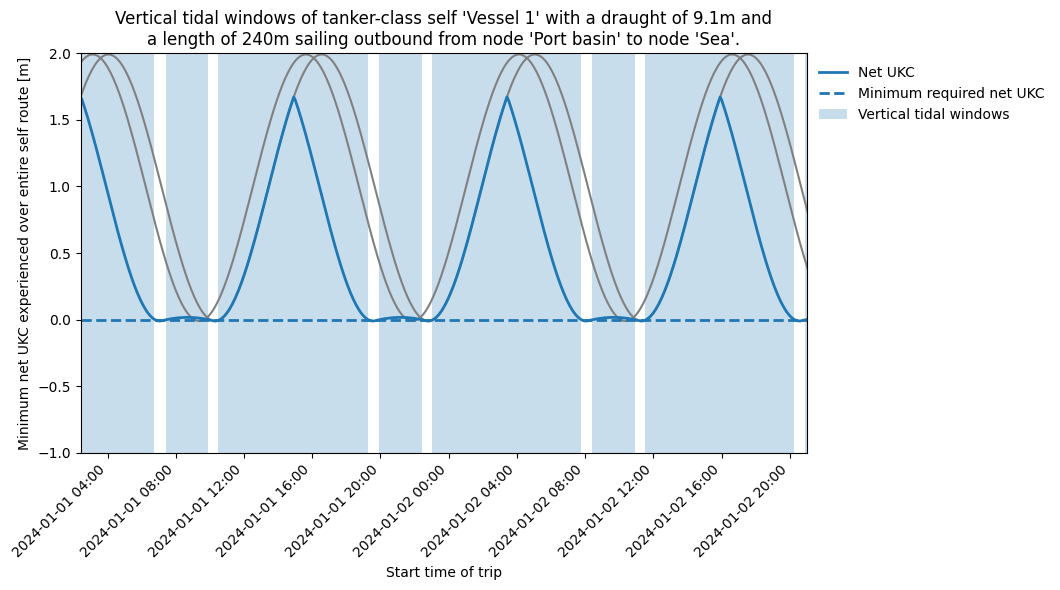

In [45]:
direction = 'outbound'
inbound_waterway_capacity_for_design_vessel, outbound_waterway_capacity_for_design_vessel, dredging, vessel = create_and_run_env_with_tidal_window(
        original_waterway_depth = 11.0, #in m (better known as NGD: nautical guaranteed depth or MBL: maintained bed level)
        added_depth = 1.7763568394002505e-15,
        waterway_length = 50000, #in m 
        ukc_percentage = 10.0, #in % of draught (10% of draught is common)
        tidal_range_sea = 2.0, #in m
        tidal_period = 12.50, # hrs (semi-diurnal tide, most common tide)
        tidal_amplication = 1.0 / 10000, #in m^-1 (amplification factor per 10 km: 1.0/10000 = not damping / amplifying)
        tidal_propagation_speed = 15, # m/s (could be calculated using np.sqrt(9.81*waterway_depth))
        interarrival_time = pd.Timedelta(minutes=20),
        vessel_draught = 7, #in m
        vessel_beam = 30,
        vessel_speed = 6.0, # m/s (common speed in confined waterways)
        vessel_loading_factor = 30.0, #in % of draught (+ = loading when export terminal, - = unloading when import terminal, 30% is common)
    )

trip_index = 0
if direction == 'outbound':
    trip_index = 1
    
net_UKC = vessel.create_plot_vertical_tidal_window(trip_index=trip_index,plot=True)[-1]

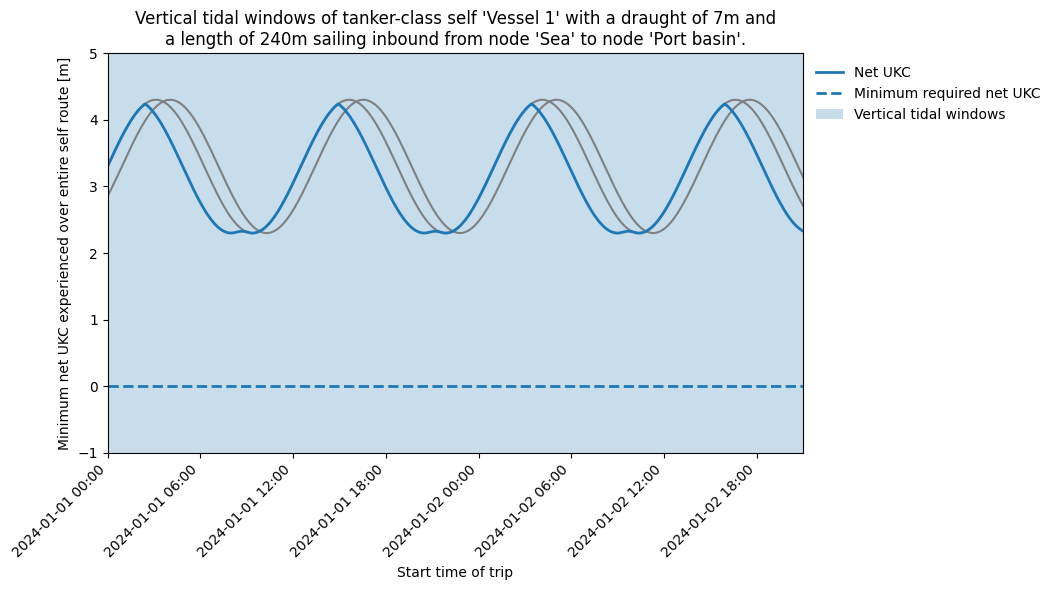

In [46]:
netuks = vessel.create_plot_vertical_tidal_window(trip_index=0,plot=True)[-1]

<Axes: >

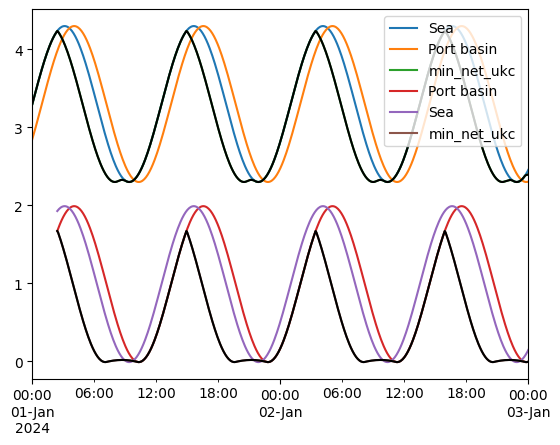

In [47]:
fig, ax = plt.subplots()
netuks.plot(ax=ax)
netuks['min_net_ukc'].plot(ax=ax, color='k')
net_UKC.plot(ax=ax)
net_UKC['min_net_ukc'].plot(ax=ax, color='k')

**Create plot**

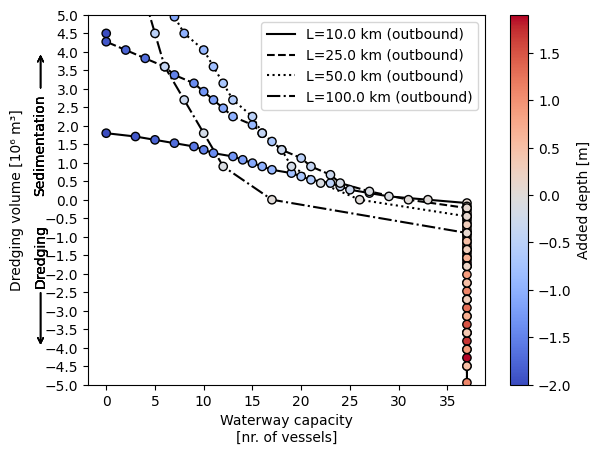

In [48]:
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots()
min_depth = 0.
max_depth = 0.
bound = 'outbound'

water_transport_capacity_performances = inbound_water_transport_capacity_performances
if bound == 'outbound':
    water_transport_capacity_performances = outbound_water_transport_capacity_performances
    
for waterway_length in water_transport_capacity_performances.keys():
    filtered_water_transport_capacity_performance = {k: v for k, v in water_transport_capacity_performances[waterway_length].items() if v > -1}
    
    filtered_dredging_performance = {k: -dredging_performances[waterway_length][k] for k in filtered_water_transport_capacity_performance}
    new_min_depth = np.min(list(filtered_water_transport_capacity_performance.keys()))
    new_max_depth = np.max(list(filtered_water_transport_capacity_performance.keys())) 
    if new_min_depth <= min_depth:
        min_depth = new_min_depth
    if new_max_depth >= max_depth:
        max_depth = new_max_depth
    norm = mpl.colors.Normalize(min_depth,max_depth)
    cmap = plt.get_cmap('coolwarm')
    
    if min_depth >= 0.:
        cmap = mcolors.LinearSegmentedColormap.from_list(
            'coolwarm',
            cmap(np.linspace(0.5, 1, 256))
        )
        norm = mpl.colors.Normalize(new_min_depth-1.,max_depth)

# for waterway_length in water_transport_capacity_performances.keys():
#     filtered_water_transport_capacity_performance = {k: v for k, v in water_transport_capacity_performances[waterway_length].items() if v > -1}
#     filtered_dredging_performance = {k: -dredging_performances[waterway_length][k] for k in filtered_water_transport_capacity_performance}

for i, waterway_length in enumerate(water_transport_capacity_performances.keys()):
    filtered_water_transport_capacity_performance = {k: v for k, v in water_transport_capacity_performances[waterway_length].items() if v > -1}
    filtered_dredging_performance = {k: -dredging_performances[waterway_length][k] for k in filtered_water_transport_capacity_performance}

    
    x_vals = list(filtered_water_transport_capacity_performance.values())
    #y_vals = list(filtered_dredging_performance.values())
    y_vals = np.array(list(filtered_dredging_performance.values())) / 1e6

    line_styles = ['-', '--', ':', '-.']
    line_style = line_styles[i % len(line_styles)]  # Afwisselen van lijnstijlen

    line, = ax.plot(
        x_vals,
        y_vals,
        label=f'L={waterway_length/1000} km ({bound})',
        zorder=-1,
        linestyle = line_style,
        color = 'black', 
    )
    cbar = ax.scatter(
        x_vals,
        y_vals,
        c=filtered_dredging_performance.keys(),
        cmap=cmap,
        norm = norm,
        edgecolor=line.get_color(),
    )
    
    ax.set_xlabel('Waterway capacity\n[nr. of vessels]')
    ax.set_ylabel('Dredging volume [10⁶ m³]', labelpad=15)
    # Dredging (pijl naar beneden)
    ax.annotate(
        'Dredging',
        xy=(-0.12, 0.10),       # punt waar pijl naartoe wijst
        xytext=(-0.12, 0.35),   # waar tekst staat
        xycoords='axes fraction',
        textcoords='axes fraction',
        arrowprops=dict(arrowstyle='->'),
        ha='center',
        va='center',
        rotation=90
    )

# Sedimentation (pijl naar boven)
    ax.annotate(
        'Sedimentation',
        xy=(-0.12, 0.90),
        xytext=(-0.12, 0.65),
        xycoords='axes fraction',
        textcoords='axes fraction',
        arrowprops=dict(arrowstyle='->'),
        ha='center',
        va='center',
        rotation=90
    )

    ax.set_ylim(-5, 5)
    ax.yaxis.set_major_locator(MultipleLocator(0.5))

ax.legend()
fig.colorbar(cbar, label='Added depth [m]')

fig.savefig('figures/Capacity_changing_waterway_lengths_outbound.png', dpi=300)

plt.show()